In [1]:
import pandas as pd
import numpy as np
import glob, os
from sklearn.model_selection import train_test_split

CSV_FOLDER = r"c:\Users\pauls\OneDrive\desktop\Vel-Tech-Summer-Internship\stockData"

all_files = glob.glob(os.path.join(CSV_FOLDER, "*.csv"))
df_list = []
for f in all_files:
    tmp = pd.read_csv(f)
    df_list.append(tmp)

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip().str.lower()

# Fix duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

print("Step 1 - Shape after load:", df.shape)
print("Columns:", df.columns.tolist())

# Parse date and sort
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print("Step 2 - Null dates:", df['date'].isnull().sum())
print("Step 3 - Shape after sort:", df.shape)

# Target variable
df['target'] = (df.groupby('symbol')['close']
                  .shift(-1) > df['close']).astype(int)

# Features
df['daily_range'] = df['high'] - df['low']
df['pct_change']  = df.groupby('symbol')['close'].pct_change()
df['vwap_diff']   = df['close'] - df['vwap']
df['delivery_pct'] = df['%deliverble'].fillna(0)

print("Step 4 - Shape before dropna:", df.shape)

FEATURES = ['open', 'high', 'low', 'close', 'volume',
            'prev close', 'vwap', 'daily_range',
            'pct_change', 'vwap_diff', 'delivery_pct']

df = df.dropna(subset=FEATURES + ['target'])

print("Step 5 - Shape after dropna:", df.shape)

X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Class balance:\n", y.value_counts(normalize=True))

C:\Users\pauls\AppData\Local\Temp\ipykernel_404\1287464541.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


Step 1 - Shape after load: (470434, 18)
Columns: ['date', 'symbol', 'series', 'prev close', 'open', 'high', 'low', 'last', 'close', 'vwap', 'volume', 'turnover', 'trades', 'deliverable volume', '%deliverble', 'company name', 'industry', 'isin code']


C:\Users\pauls\AppData\Local\Temp\ipykernel_404\1287464541.py:24: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')


Step 2 - Null dates: 50
Step 3 - Shape after sort: (470434, 18)


C:\Users\pauls\AppData\Local\Temp\ipykernel_404\1287464541.py:36: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['pct_change']  = df.groupby('symbol')['close'].pct_change()


Step 4 - Shape before dropna: (470434, 23)
Step 5 - Shape after dropna: (470319, 23)

Train: (376255, 11), Test: (94064, 11)
Class balance:
 target
0    0.748292
1    0.251708
Name: proportion, dtype: float64


In [2]:
import warnings
warnings.filterwarnings('ignore')

import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# scale_pos_weight fixes the class imbalance!
# Formula: count of 0s / count of 1s
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"scale_pos_weight = {spw}")

base_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=spw       
)
base_model.fit(X_train, y_train)

# Save as best_model.pkl
joblib.dump(base_model, 'best_model.pkl')

# Baseline F1 on test set
y_pred_base = base_model.predict(X_test)
baseline_f1 = f1_score(y_test, y_pred_base, average='weighted')
print(f"\nBaseline F1-weighted : {baseline_f1:.4f}")

# Cross-validation (5 mini quizzes)
cv_scores = cross_val_score(base_model, X_train, y_train,
                            cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"CV Mean  : {cv_scores.mean():.4f}")
print(f"CV Std   : {cv_scores.std():.4f}")

scale_pos_weight = 2.98

Baseline F1-weighted : 0.7665
CV Mean  : 0.7644
CV Std   : 0.0014


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7]
}
print("Total combinations:", 3 * 3 * 3, "× 5 folds =", 3*3*3*5, "fits")

fresh_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=2.98     
)

grid = GridSearchCV(
    fresh_model,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest params :", grid.best_params_)
print("Best CV F1  :", f"{grid.best_score_:.4f}")

Total combinations: 27 × 5 folds = 135 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits


        Model  F1 Score Change
Default model    0.7665      -
  Tuned model    0.7663 -0.02%


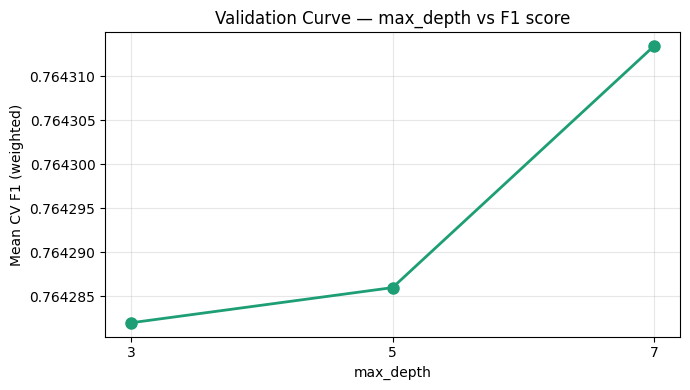


tuned_model.pkl saved successfully!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

# Before vs After table
comparison = pd.DataFrame({
    'Model'    : ['Default model', 'Tuned model'],
    'F1 Score' : [round(baseline_f1, 4), round(tuned_f1, 4)],
    'Change'   : ['-', f"{(tuned_f1 - baseline_f1)*100:+.2f}%"]
})
print(comparison.to_string(index=False))

# Validation curve — max_depth vs score
results    = pd.DataFrame(grid.cv_results_)
depth_vals = [3, 5, 7]
mean_scores = []
for d in depth_vals:
    mask = results['param_max_depth'] == d
    mean_scores.append(results.loc[mask, 'mean_test_score'].mean())

plt.figure(figsize=(7, 4))
plt.plot(depth_vals, mean_scores, marker='o',
         color='#1D9E75', linewidth=2, markersize=8)
plt.title('Validation Curve — max_depth vs F1 score')
plt.xlabel('max_depth')
plt.ylabel('Mean CV F1 (weighted)')
plt.xticks(depth_vals)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('validation_curve.png', dpi=150)
plt.show()

joblib.dump(tuned_model, 'tuned_model.pkl')
print("\ntuned_model.pkl saved successfully!")